# Datalab 2

## groep 6 : 
- Ardjun Debi - Tewarie (25032895)
- Azfar Mohab Ali (25026356)
- Tesja Kartomo (25035193)
- Shelby Gibbs (18005055)
# [HERKANSINGEN]
- [Sprint 3 visualisaties (scatterplots)](#visualisaties-van-teameigenschappen-en-punten) - Feedback van de herkansing hiervan: er zijn geen visualisaties voor class variabelen. Er is maar 1 scatterplot
- [Sprint 3 aantal wedstrijden per seizoen (kalenderjaar 2010)](#1B:-Aantal-wedstrijden-in-het-kalenderjaar-2010-per-seizoen) - we haden matig (0.5 punten) omdat de berekening onvolledig was. we hebben aangepast en de query correct uitgevoerd zodat het de aantal wedstrijden toont per seizoen in het kalenderjar van 2010

## Import en connectie met de database

Hier maken we gebruik van een `DatabaseViewer` class die de verbinding met de database (`./assets/database.sqlite`) opzet en functies bevat om SQL queries uit te voeren en zowel volledige resultaten als een preview (eerste rij) weer te geven.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class DatabaseViewer:
    """
    Klasse voor het verbinden met en bekijken van data uit een SQLite database.

    Attributes
    ----------
    db_path : str
        Pad naar de database.
    conn : sqlite3.Connection
        Actieve databaseverbinding.
    """

    def __init__(self, db_path="./assets/database.sqlite"):
        """
        Initialiseert de databaseverbinding.

        Parameters
        ----------
        db_path : str, optional
            Pad naar de SQLite database (standaard './assets/database.sqlite').
        """
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path)
        print(f"Database connectie is gemaakt met: {db_path}")

    def show_query(self, query):
        """
        Voert een SQL-query uit.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        DataFrame
            Toont het resultaat als pandas DataFrame.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df)
        return df

    def show_head_query(self, query):
        """
        Voert een SQL-query uit en toont de eerste rij.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        Eerste rij dataframe
            Toont alleen de eerste rij van het resultaat.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df.head(1))


bar = DatabaseViewer()


Database connectie is gemaakt met: ./assets/database.sqlite


## Stap 1: team_api_id van Barcelona vinden

- **Stap 1:** Zoek in de tabel **Team** naar de `team_api_id` van **FC Barcelona**. Deze identifier gebruiken we later om wedstrijden van dit team te vinden.

In [2]:
# stap 1: vind de team_api_id van FC Barcelona
bar.show_query("""
SELECT team_long_name, team_api_id
FROM Team
WHERE team_long_name = 'FC Barcelona';
""")


,team_long_name,team_api_id
0,FC Barcelona,8634


,team_long_name,team_api_id
0,FC Barcelona,8634


## Stap 2: Matches van Barcelona vinden

- **Stap 2:** Zoekt naar wedstrijden waarin Barcelona speelt door `team_api_id` (8634) in de tabel **Match** te filteren. Hierbij kijken we zowel naar `home_team_api_id` als `away_team_api_id`.

In [3]:
# stap 2: vind de matches door middel van team_api_id van barcelona
bar.show_query("""
SELECT
  Match.id,
  Match.season,
  Match.country_id,
  Match.league_id,
  Match.home_team_api_id,
  Match.away_team_api_id
FROM Match
WHERE Match.home_team_api_id = 8634
   OR Match.away_team_api_id = 8634
LIMIT 5;
          
""")

,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


## Stap 3: League van Barcelona bepalen

- **Stap 3.1:** Zoek de `league_id` van een wedstrijd waarin Barcelona speelt.  
- **Stap 3.2:** Zoek de `country_id` van deze wedstrijd.  
- **Stap 3.3:** Gebruik de `country_id` om de naam van de **League** te vinden.

In [4]:
# stap 3: vind de league_id's en de naam van de league van de matches van barcelona
# stap 3.1: vind de league id
bar.show_query(
"""
SELECT Match.league_id
FROM Match
WHERE Match.home_team_api_id = 8634 OR Match.away_team_api_id = 8634
LIMIT 1;
""")

# stap 3.2: vind eerste de country id om makkelijjker te zoeken naar de name van de League
bar.show_query(
"""
SELECT Match.country_id
FROM Match
WHERE home_team_api_id = 8634
LIMIT 1
"""
)
# stap 3.3 vind nu de naam van de league:
bar.show_query(
"""
SELECT League.Name
FROM League
WHERE country_id = 21518
LIMIT 1
"""
)



,league_id
0,21518


,country_id
0,21518


,name
0,Spain LIGA BBVA


,name
0,Spain LIGA BBVA


## Belangrijke variablen
- Team : **Barcelona**
- `Team_api_id`, `home_team_api_id`, `away_team_api_id` : 8634
- `Country_id`, `League_id` : 21518
- `League.Name` : Spain LIGA BBVA

## Relaties:
### Tabel met relaties:
| Kolom| Van tabel | Naar tabel | Naar kolom | Beschrijving|
| ------------------ | ----------------- | ---------- | ------------------ | ----------------------------------------------------------------------- |
| country_id | League| Country| id | Geeft aan in welk land de **competitie plaatsvindt**. |
| country_id | Match | Country| id | Geeft aan in welk land de **wedstrijd gespeeld** wordt. |
| league_id| Match | League | id | **Verbindt** een wedstrijd aan de competitie waarin deze gespeeld wordt.|
| home_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **thuiswedstrijd** speelt.|
| away_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **uitwedstrijd** speelt.|
| player_api_id| Player_Attributes | Player | player_api_id| **Verbindt** de spelers attributen met een specifieke speler.|
| player_fifa_api_id | Player_Attributes | Player | player_fifa_api_id | Alternatieve identifier uit FIFA dat die attributen aan een speler **koppelt**. |
| team_api_id| Team_Attributes | Team | team_api_id| **Verbindt** team attributen met een specifiek team. |
| team_fifa_api_id | Team_Attributes | Team | team_fifa_api_id | FIFA identifier die team attributen **koppelt** aan een team.|
| away_player_1| Match | Player | player_api_id| Eerste speler van het **uit team** in de wedstrijd. |
| away_player_2| Match | Player | player_api_id| Tweede speler van het **uit team** in de wedstrijd. |
| away_player_3| Match | Player | player_api_id| Derde speler van het **uit team** in de wedstrijd.|
| away_player_4| Match | Player | player_api_id| Vierde speler van het **uit team** in de wedstrijd. |
| away_player_5| Match | Player | player_api_id| Vijfde speler van het **uit team** in de wedstrijd. |
| away_player_6| Match | Player | player_api_id| Zesde speler van het **uit team** in de wedstrijd.|
| away_player_7| Match | Player | player_api_id| Zevende speler van het **uit team** in de wedstrijd.|
| away_player_8| Match | Player | player_api_id| Achtste speler van het **uit team** in de wedstrijd.|
| away_player_9| Match | Player | player_api_id| Negende speler van het **uit team** in de wedstrijd.|
| away_player_10 | Match | Player | player_api_id| Tiende speler van het **uit team** in de wedstrijd. |
| away_player_11 | Match | Player | player_api_id| Elfde speler van het **uit team** in de wedstrijd.|
| home_player_1| Match | Player | player_api_id| Eerste speler van het **thuis team** in de wedstrijd. |
| home_player_2| Match | Player | player_api_id| Tweede speler van het **thuis team** in de wedstrijd. |
| home_player_3| Match | Player | player_api_id| Derde speler van het **thuis team** in de wedstrijd.|
| home_player_4| Match | Player | player_api_id| Vierde speler van het **thuis team** in de wedstrijd. |
| home_player_5| Match | Player | player_api_id| Vijfde speler van het **thuis team** in de wedstrijd. |
| home_player_6| Match | Player | player_api_id| Zesde speler van het **thuis team** in de wedstrijd.|
| home_player_7| Match | Player | player_api_id| Zevende speler van het **thuis team** in de wedstrijd.|
| home_player_8| Match | Player | player_api_id| Achtste speler van het **thuis team** in de wedstrijd.|
| home_player_9| Match | Player | player_api_id| Negende speler van het **thuis team** in de wedstrijd.|
| home_player_10 | Match | Player | player_api_id| Tiende speler van het **thuis team** in de wedstrijd. |
| home_player_11 | Match | Player | player_api_id| Elfde speler van het **thuis team** in de wedstrijd.|

### Samengevat:
Elke wedstrijd is gekoppeld aan een competitie via `league_id` en aan twee teams via `home_team_api_id` en `away_team_api_id`, die verwijzen naar de tabel **Team**.

De spelers die in een wedstrijd spelen staan in de kolommen `home_player_1` t/m `home_player_11` en `away_player_1` t/m `away_player_11`. Deze verwijzen naar de tabel **Player**.

De tabellen `Player_Attributes` en `Team_Attributes` bevatten extra informatie over **spelers** en **teams** en zijn gekoppeld via hun **API identifiers**.


## Ranglijst
Seizoen : 2015

In [5]:
bar.show_query(
"""
SELECT date
FROM match 
WHERE date LIKE "2015%"
""")

,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


In [6]:
# Ranglijst - La Liga seizoen 2015/2016
import sqlite3
import pandas as pd

# Verbinding maken met de database
conn = sqlite3.connect("./assets/database.sqlite")


def get_ranglijst(conn, league_id, seizoen):
    """
    Berekent de ranglijst van een competitie voor een gegeven seizoen.

    Parameters:
        conn       : sqlite3 verbinding met de database
        league_id  : int, de league_id van de competitie (bijv. 21518 voor La Liga)
        seizoen    : str, het seizoen als string (bijv. '2015/2016')

    Returns:
        pd.DataFrame met kolommen: Positie, Team, GS, W, G, V, DV, DT, DS, Punten
        gesorteerd op punten (desc), dan doelsaldo (desc), dan doelpunten voor (desc)
    """

    # Stap 1: Haal alle wedstrijden op uit het gekozen seizoen en competitie
    query = f"""
        SELECT
            m.home_team_api_id AS home_id,
            m.away_team_api_id AS away_id,
            m.home_team_goal   AS home_goal,
            m.away_team_goal   AS away_goal
        FROM Match m
        WHERE m.league_id = {league_id}
          AND m.season = '{seizoen}'
    """
    matches = pd.read_sql_query(query, conn)

    # Stap 2: Haal de teamnamen op zodat we ID's kunnen omzetten naar namen
    team_query = "SELECT team_api_id, team_long_name FROM Team"
    teams = pd.read_sql_query(team_query, conn)
    team_dict = dict(zip(teams['team_api_id'], teams['team_long_name']))

    # Stap 3: Maak een lege statistieken-dictionary aan voor elk uniek team
    alle_teams = set(matches['home_id']).union(set(matches['away_id']))
    stats = {t: {'GS': 0, 'W': 0, 'G': 0, 'V': 0, 'DV': 0, 'DT': 0} for t in alle_teams}

    # Stap 4: Loop door alle wedstrijden en bereken de statistieken per team
    for _, row in matches.iterrows():
        h, a   = row['home_id'],   row['away_id']
        hg, ag = row['home_goal'], row['away_goal']

        # Aantal gespeelde wedstrijden ophogen voor beide teams
        stats[h]['GS'] += 1
        stats[a]['GS'] += 1

        # Doelpunten bijhouden voor beide teams
        stats[h]['DV'] += hg
        stats[h]['DT'] += ag
        stats[a]['DV'] += ag
        stats[a]['DT'] += hg

        # Bepaal de uitslag winst/gelijk/verlies
        if hg > ag:        # Thuisploeg wint
            stats[h]['W'] += 1
            stats[a]['V'] += 1
        elif hg < ag:      # Uitploeg wint
            stats[a]['W'] += 1
            stats[h]['V'] += 1
        else:              # Gelijkspel
            stats[h]['G'] += 1
            stats[a]['G'] += 1

    # Stap 5: Zet de statistieken om naar een overzichtelijke lijst
    rijen = []
    for team_id, s in stats.items():
        punten = s['W'] * 3 + s['G']   # Winst = 3 punten, gelijk = 1 punt
        ds     = s['DV'] - s['DT']     # Doelsaldo = doelpunten voor - tegen

        rijen.append({
            'Team'   : team_dict.get(team_id, str(team_id)),
            'GS'     : s['GS'],
            'W'      : s['W'],
            'G'      : s['G'],
            'V'      : s['V'],
            'DV'     : s['DV'],
            'DT'     : s['DT'],
            'DS'     : ds,
            'Punten' : punten
        })

    # Stap 6: Maak een DataFrame en sorteer op punten, doelsaldo, doelpunten voor
    ranglijst = pd.DataFrame(rijen)
    ranglijst = ranglijst.sort_values(
        by=['Punten', 'DS', 'DV'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    # Positie begint bij 1 in plaats van 0
    ranglijst.index += 1
    ranglijst.index.name = 'Positie'

    return ranglijst


# Roep de functie aan voor La Liga seizoen 2015/2016
ranglijst_2015 = get_ranglijst(conn, league_id=21518, seizoen='2015/2016')
display(ranglijst_2015)

,Team,GS,W,G,V,DV,DT,DS,Punten
Positie,,,,,,,,,
1,FC Barcelona,38,29,4,5,112,29,83,91
2,Real Madrid CF,38,28,6,4,110,34,76,90
3,Atlético Madrid,38,28,4,6,63,18,45,88
4,Villarreal CF,38,18,10,10,44,35,9,64
5,Athletic Club de Bilbao,38,18,8,12,58,45,13,62
6,RC Celta de Vigo,38,17,9,12,51,59,-8,60
7,Sevilla FC,38,14,10,14,51,50,1,52
8,Málaga CF,38,12,12,14,38,35,3,48
9,Real Sociedad,38,13,9,16,45,48,-3,48


## Uitleg van de ranglijst

De ranglijst laat zien hoe alle clubs in La Liga het hebben gedaan in het seizoen 2015/2016. Hieronder leggen we uit wat elke kolom betekent:

- **Positie** – De plek van het team in de competitie, gebaseerd op het aantal punten.
- **Team** – De naam van de voetbalclub.
- **GS** – Gespeelde wedstrijden. Hoeveel wedstrijden het team heeft gespeeld dat seizoen.
- **W** – Gewonnen. Het aantal wedstrijden dat het team heeft gewonnen.
- **G** – Gelijk. Het aantal wedstrijden dat gelijkgespeeld is.
- **V** – Verloren. Het aantal wedstrijden dat het team heeft verloren.
- **DV** – Doelpunten Vóór. Het totaal aantal doelpunten dat het team zelf heeft gescoord.
- **DT** – Doelpunten Tégen. Het totaal aantal doelpunten dat het team heeft weggegeven.
- **DS** – Doelsaldo. Het verschil tussen DV en DT (DV - DT). Een positief getal betekent dat een team meer heeft gescoord dan weggegeven.
- **Punten** – Het totaal aantal punten. Een overwinning levert 3 punten op, een gelijkspel 1 punt en een verlies 0 punten. Bij een gelijk aantal punten wordt gekeken naar het doelsaldo.

------------------------------------------------------------------------------------------------------------------------

# SPRINT 3
## 1A: Aantal wedstrijden per seizoen
Hier hebben we met behulp van SQL het aantal wedstrijden per seizoen van FC Barcelona kunnen aan tonen.


Stap 1: Tel, met gebruik van `league_id`, `home_team_api_id` en `away_team_api_id`, de aantal wedstrijden per seizoen.

In [7]:
#Stap 1: Toon het aantal wedstrijden per seizoen
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE home_team_api_id = 8634 
   OR away_team_api_id = 8634
GROUP BY league.name, season;
"""
)

,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


### 1B: Aantal wedstrijden in het kalenderjaar 2010 per seizoen


In [8]:
#Het aantal wedstrijden tonen per seizoen in het kalenderjaar 2010
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE (home_team_api_id = 8634 OR away_team_api_id = 8634)
  AND date >= '2010-01-01'
  AND date < '2011-01-01'
GROUP BY league.name, season;
"""
)

,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2009/2010,23
1,Spain LIGA BBVA,2010/2011,16


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2009/2010,23
1,Spain LIGA BBVA,2010/2011,16


###  1C: Hoeveelheid punten ieder team had gehaald per seizoen 

In [9]:
#Stap 3: toon hoeveel punten ieder team in ons compititie gehaald heeft per seizoen
bar.show_query(
"""SELECT
    league.name AS league,
    season,
    team.team_long_name AS team,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN league ON match.league_id = league.id
INNER JOIN team ON team.team_api_id = match.home_team_api_id 
               OR team.team_api_id = match.away_team_api_id
WHERE league.name = 'Spain LIGA BBVA'
GROUP BY league.name, season, team.team_api_id
ORDER BY season, punten DESC;
"""
)

# case doet hier dus het volgende: als het team de thuisploeg is en wint, krijgt het 3 punten. Als het team de uitploeg is en wint, krijgt het ook 3 punten. Als er een gelijkspel is, krijgen beide teams 1 punt. In alle andere gevallen (verlies) krijgt het team 0 punten.



,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


### 1D: Rank tonen op ranglijst


In [10]:
#Stap 3: Toon op welke plaats Barcelona is geëindigd in de ranglijst competitie per seizoen

# WITH ranglijst AS (...) -> subquery dat eerst de volledige ranglijst met alle teams berekent.
# RANK() OVER (PARTITION BY season ...) -> geeft elke team een eindpositie per seizoen.
# Buitenste WHERE team = 'FC Barcelona' -> filtert pas daarna op Barca, zodat de positie correct is berekend op basis van alle teams.
# Het resultaat toont per seizoen hoeveel punten Barca had en op welke positie ze eindigden.
bar.show_query(
"""WITH ranglijst AS (
    SELECT
        league.name AS league,
        season,
        team.team_long_name AS team,
        SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) AS punten,
        RANK() OVER (PARTITION BY season ORDER BY SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) DESC) AS positie
    FROM match
    INNER JOIN league ON match.league_id = league.id
    INNER JOIN team ON team.team_api_id = match.home_team_api_id 
                   OR team.team_api_id = match.away_team_api_id
    WHERE league.name = 'Spain LIGA BBVA'
    GROUP BY league.name, season, team.team_api_id
)
SELECT league, season, team, punten, positie
FROM ranglijst
WHERE team = 'FC Barcelona'
ORDER BY season;
"""
)




,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


## stappen voor 2a

We hebben een dataframe met punten per team **samengevoegd** met teameigenschappen uit **Team_Attributes** op basis van **team_api_id**. Hierdoor hebben we één dataset voor verdere analyse.

**Teameigenschappen**:

- `buildUpPlaySpeed`
- `buildUpPlayDribbling`
- `buildUpPlayPassing`
- `chanceCreationPassing`
- `chanceCreationCrossing`
- `chanceCreationShooting`
- `defencePressure`
- `defenceAggression`
- `defenceTeamWidth`

In [11]:
punten_df = bar.show_query(
"""SELECT
    season,
    team.team_long_name AS team,
    team.team_api_id,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN team 
    ON team.team_api_id = match.home_team_api_id 
    OR team.team_api_id = match.away_team_api_id
GROUP BY match.season, team.team_long_name, team.team_api_id
ORDER BY match.season, punten DESC
"""
)


,season,team,team_api_id,punten
0,2008/2009,Manchester United,10260,90
1,2008/2009,FC Barcelona,8634,87
2,2008/2009,Liverpool,8650,86
3,2008/2009,Rangers,8548,86
4,2008/2009,Inter,8636,84
...,...,...,...,...
1476,2015/2016,Hannover 96,9904,25
1477,2015/2016,De Graafschap,8526,23
1478,2015/2016,ES Troyes AC,10242,18
1479,2015/2016,SC Cambuur,7788,18


In [12]:
# stap 2. Team attributes ophalen
teameig_df = bar.show_query("""
SELECT
    team_api_id,
    date,
    buildUpPlaySpeed,
    buildUpPlayDribbling,
    buildUpPlayPassing,
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,
    defencePressure,
    defenceAggression,
    defenceTeamWidth
FROM Team_Attributes
GROUP BY team_api_id""")

# stap 3. Samenvoegen 
samengevoegd_df = punten_df.merge(teameig_df, on="team_api_id")

display(samengevoegd_df.head(10))


,team_api_id,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,1601,2010-02-22 00:00:00,30,NaN,40,50,35,70,65,60,50
1,1773,2012-02-22 00:00:00,52,NaN,50,50,53,54,43,44,50
2,1957,2010-02-22 00:00:00,30,NaN,50,45,35,70,70,70,70
3,2033,2010-02-22 00:00:00,45,NaN,55,50,60,45,50,45,60
4,2182,2010-02-22 00:00:00,40,NaN,35,45,40,70,60,55,45
...,...,...,...,...,...,...,...,...,...,...,...
283,10281,2010-02-22 00:00:00,55,NaN,40,45,30,60,30,65,30
284,108893,2010-02-22 00:00:00,50,NaN,65,30,35,30,30,50,35
285,158085,2014-09-19 00:00:00,69,66.0,39,55,59,46,35,37,37
286,208931,2014-09-19 00:00:00,32,46.0,31,47,36,54,46,44,51


,season,team,team_api_id,punten,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,2008/2009,Manchester United,10260,90,2010-02-22 00:00:00,70,NaN,45,45,70,65,40,50,40
1,2008/2009,FC Barcelona,8634,87,2010-02-22 00:00:00,42,NaN,30,65,40,70,70,30,70
2,2008/2009,Liverpool,8650,86,2010-02-22 00:00:00,50,NaN,35,50,60,70,40,60,40
3,2008/2009,Rangers,8548,86,2010-02-22 00:00:00,65,NaN,50,70,70,70,60,70,70
4,2008/2009,Inter,8636,84,2010-02-22 00:00:00,55,NaN,55,50,55,70,50,60,55
5,2008/2009,Chelsea,8455,83,2010-02-22 00:00:00,70,NaN,60,56,70,70,30,60,35
6,2008/2009,Celtic,9925,82,2010-02-22 00:00:00,70,NaN,70,65,70,70,60,70,70
7,2008/2009,AZ,10229,80,2010-02-22 00:00:00,55,NaN,45,40,30,60,30,30,50
8,2008/2009,Girondins de Bordeaux,9827,80,2010-02-22 00:00:00,70,NaN,35,70,50,70,55,70,70
9,2008/2009,FC Zürich,10243,79,2010-02-22 00:00:00,45,NaN,60,45,70,50,50,55,50


## Visualisaties van teameigenschappen en punten

We hebben onderzocht of teameigenschappen samenhangen met het aantal punten met een heatmap en een scatterplot. De meeste relaties zijn zwak.

### wat ziet er goed uit
`buildUpPlayDribbling`: positief  
`chanceCreationShooting`: positief  
`defencePressure`: positief  

teams doen het beter wanneer ze meer dribbelen, vaker op doel schieten en druk zetten in de verdediging  
de scatterplot laat zien dat teams met meer dribbelen soms meer punten halen, maar dit is niet altijd consistent

### wat kan beter
`buildUpPlayPassing`: negatief  

teams moeten minder afhankelijk zijn van het pasen.
de scatterplot laat ook zien dat er veel spreiding is, dus dribbelen alleen bepaalt het resultaat niet

## conclusie
teameigenschappen hebben invloed, maar deze is klein en teams presteren beter met direct en aanvallend spel.

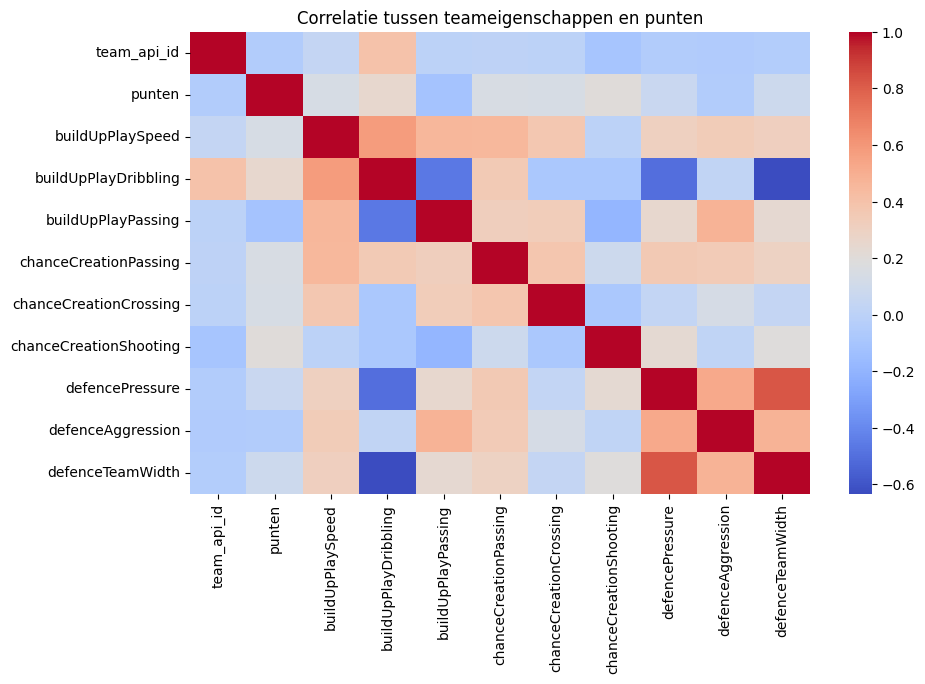

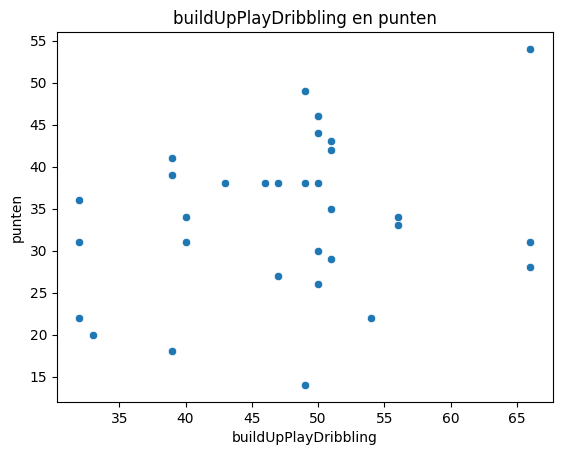

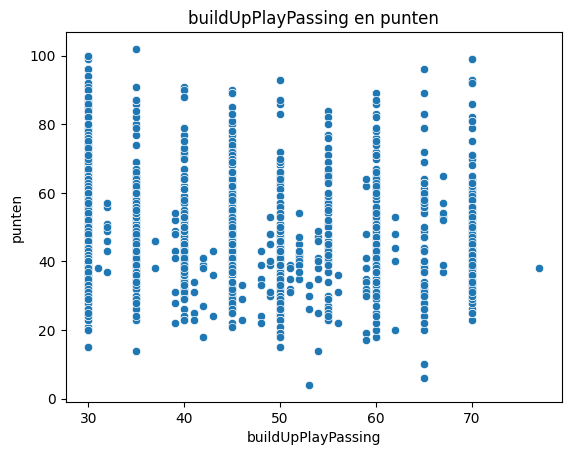

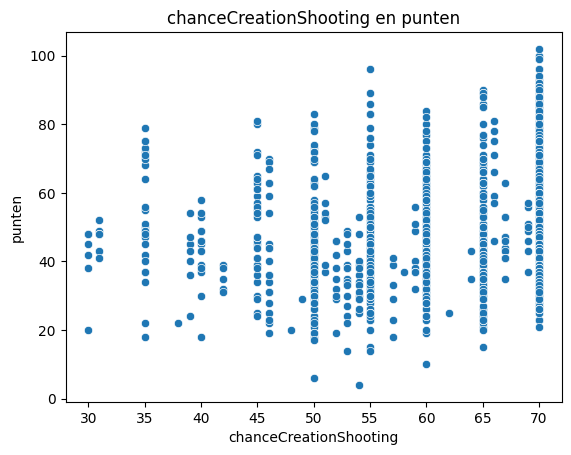

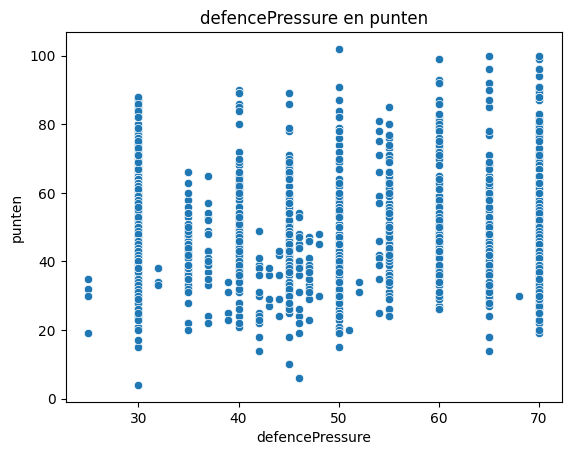

In [13]:

# heatmap
corr = samengevoegd_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlatie tussen teameigenschappen en punten")
plt.show()

variabelen = [
    "buildUpPlayDribbling",
    "buildUpPlayPassing",
    "chanceCreationShooting",
    "defencePressure"
]

for var in variabelen:
    sns.scatterplot(data=samengevoegd_df, x=var, y="punten")
    plt.title(f"{var} en punten")
    plt.show()



## SPRINT 4 

Opdracht 1a: Maak een nieuw dataframe waarin voor iedere speler het gemiddelde van alle relevante spelerseigenschappen ('Player_Attributes') staat 

- we selecteren alle relevante kolommen van `player_attributes` behalve `player_api_id`
- we het gemiddelde per speler
- groupby("player_api_id") = groepeer alle rijen met dezelfde speler
- [relevante_kolommen] = alleen de statistieken meenemen, niet de ID
- .mean() = bereken het gemiddelde per kolom per speler
- .reset_index() = zet player_api_id terug als gewone kolom (niet als index)

In [14]:
def get_gemiddelde_speler_attributen(conn):
    """
    Berekent het gemiddelde van alle spelersstatistieken per speler.

    Elke speler heeft meerdere rijen in de database (één per seizoen/meting).
    Deze functie groepeert alle metingen per speler en berekent het gemiddelde
    van elke statistiek, zodat je één overzichtelijke rij per speler krijgt.

    Parameters
    ----------
    conn : sqlite3.Connection
        De actieve verbinding met de SQLite database.
        Wordt gebruikt om de SQL-query uit te voeren.

    Returns
    -------
    pd.DataFrame
        Een nieuw DataFrame met per speler (player_api_id) het gemiddelde
        van alle relevante spelereigenschappen, afgerond op 2 decimalen.
        Bevat 11.060 spelers en 36 kolommen.
    """

    # we halen alle relevante kolommen op uit Player_Attributes
    # we selecteren handmatig alle statistieken die we willen meenemen
    query = """
    SELECT
        player_api_id,
        overall_rating,
        potential,
        crossing,
        finishing,
        heading_accuracy,
        short_passing,
        volleys,
        dribbling,
        curve,
        free_kick_accuracy,
        long_passing,
        ball_control,
        acceleration,
        sprint_speed,
        agility,
        reactions,
        balance,
        shot_power,
        jumping,
        stamina,
        strength,
        long_shots,
        aggression,
        interceptions,
        positioning,
        vision,
        penalties,
        marking,
        standing_tackle,
        sliding_tackle,
        gk_diving,
        gk_handling,
        gk_kicking,
        gk_positioning,
        gk_reflexes
    FROM Player_Attributes
    """

    # hier voeren we de query uit en laden het resultaat in een DataFrame
    # pd.read_sql_query combineert SQL uitvoeren + inladen in één stap
    df = pd.read_sql_query(query, conn)

    # we selecteren alle kolommen behalve player_api_id (dat is de ID, geen statistiek)
    # we maken een list comprehension
    relevante_kolommen = [col for col in df.columns if col != "player_api_id"]

    # hier berekenen we het gemiddelde per speler
    # groupby("player_api_id") = groepeer alle rijen met dezelfde speler
    # [relevante_kolommen] = alleen de statistieken meenemen, niet de ID
    # .mean() = bereken het gemiddelde per kolom per speler
    # .reset_index() = zet player_api_id terug als gewone kolom (niet als index)
    gemiddelde_df = (
        df.groupby("player_api_id")[relevante_kolommen]
        .mean()
        .reset_index()
    )

    # hier ronden we alle waarden af op 2 decimalen voor leesbaarheid
    gemiddelde_df[relevante_kolommen] = gemiddelde_df[relevante_kolommen].round(2)

    return gemiddelde_df


# als laatst roepen we de functie aan en slaan het resultaat op in speler_gem_df
speler_gem_df = get_gemiddelde_speler_attributen(bar.conn)

display(speler_gem_df.head(10))
print(f"Aantal spelers: {len(speler_gem_df)}")
print(f"Aantal kolommen: {len(speler_gem_df.columns)}")

,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2625,60.14,61.14,50.14,47.29,46.29,56.50,38.00,54.14,50.00,...,55.29,61.93,62.93,63.86,56.57,12.43,12.86,19.07,10.36,10.43
1,2752,69.38,70.38,36.43,37.43,75.33,54.81,20.43,44.86,30.43,...,52.43,35.43,71.10,70.67,65.57,11.10,6.10,7.10,9.10,15.10
2,2768,69.29,70.57,42.24,42.76,66.67,64.71,28.76,40.24,51.76,...,57.76,31.90,71.67,70.62,79.71,10.76,15.90,22.71,15.14,12.10
3,2770,71.13,73.53,61.87,67.67,67.80,72.53,67.13,75.07,79.80,...,71.60,63.93,30.20,37.53,25.00,8.67,15.67,27.20,16.33,17.00
4,2790,70.20,75.80,70.00,37.40,55.20,68.00,43.00,60.80,67.00,...,60.00,55.40,74.60,74.60,69.00,8.00,17.00,59.00,16.60,17.40
5,2796,64.60,70.53,17.93,16.07,19.73,21.20,16.00,17.93,18.53,...,27.27,21.53,17.27,17.93,17.87,73.67,59.00,59.87,57.93,69.53
6,2802,76.32,78.86,77.18,72.64,55.73,71.64,68.27,83.09,80.09,...,76.18,71.36,38.86,43.05,36.00,11.86,16.91,23.00,11.50,9.95
7,2805,72.54,77.82,54.39,41.54,53.82,75.00,26.32,55.54,56.75,...,74.07,52.11,57.86,76.21,63.36,10.11,9.29,18.79,10.18,15.54
8,2857,65.19,68.25,66.75,58.06,47.12,60.81,58.00,68.00,65.69,...,65.25,58.50,27.38,34.38,23.00,10.69,10.81,25.12,9.19,13.25
9,2862,72.91,74.56,68.26,65.88,60.00,70.29,69.85,76.79,70.62,...,70.88,73.06,22.50,23.74,22.79,9.91,15.68,18.68,11.65,8.71


Aantal spelers: 11060
Aantal kolommen: 36


## 1b: Edit de df zodat per speler hun gemiddelde rating te zien is.

- `speler_gem_df` wordt tijdelijk opgeslagen als SQL-tabel, zodat deze gebruikt kan worden in de query.
- De loops gaan langs alle thuis- en uitspelers en maken automatisch de SELECT- en LEFT JOIN-stukken.
- LEFT JOIN koppelt elke speler uit een wedstrijd aan zijn gemiddelde `overall_rating`.
- `", ".join(select_delen)` zet komma’s tussen de kolommen, omdat SQL-kolommen in SELECT gescheiden moeten worden met komma’s.
- `" ".join(join_delen)` plakt alle joins achter elkaar; hierbij zijn geen komma’s nodig.
- `UNION` wordt hier niet gebruikt. `UNION` gebruik je alleen als je meerdere SELECT resultaten onder elkaar wilt zetten.
- De `WHERE` selecteert alleen wedstrijden waarin FC Barcelona meedeed.

In [15]:
# Dataframe van opdracht 1a tijdelijk opslaan als SQL-tabel
# Zo kunnen we speler_gem_df gebruiken in een SQL-query
speler_gem_df.to_sql("speler_gem_df", bar.conn, if_exists="replace", index=False)

# We willen home en away spelers meenemen
teams = ["home", "away"]

# Hier slaan we de stukjes SQL tijdelijk in op
join_delen = []
select_delen = []

# Loop door home en away en door speler 1 t/m 11
for team in teams:
    for nummer in range(1, 12):
        alias = f"{team}_{nummer}"

        # Kolommen maken voor de rating van elke speler
        select_delen.append(
            f"{alias}.overall_rating AS {team}_Player_{nummer}_overall_rating"
        )

        # Speler uit Match koppelen aan zijn gemidelde rating
        join_delen.append(f"""
            LEFT JOIN speler_gem_df AS {alias}
                ON m.{team}_player_{nummer} = {alias}.player_api_id
        """)

# Query maken voor alle wedstrijden van FC Barcelona
query = f"""
SELECT
    m.id AS match_id,
    m.season,
    m.date,
    {", ".join(select_delen)}
FROM Match AS m
{" ".join(join_delen)}
WHERE m.home_team_api_id = 8634
   OR m.away_team_api_id = 8634
ORDER BY m.date;
"""

# Testen
wedstrijd_rating_df = pd.read_sql_query(query, bar.conn)
wedstrijd_rating_df.head(11)

,match_id,season,date,home_Player_1_overall_rating,home_Player_2_overall_rating,home_Player_3_overall_rating,home_Player_4_overall_rating,home_Player_5_overall_rating,home_Player_6_overall_rating,home_Player_7_overall_rating,...,away_Player_2_overall_rating,away_Player_3_overall_rating,away_Player_4_overall_rating,away_Player_5_overall_rating,away_Player_6_overall_rating,away_Player_7_overall_rating,away_Player_8_overall_rating,away_Player_9_overall_rating,away_Player_10_overall_rating,away_Player_11_overall_rating
0,21521,2008/2009,2008-08-31 00:00:00,71.14,66.92,NaN,68.50,69.06,65.50,66.53,...,84.20,85.89,76.43,79.53,87.64,85.03,88.32,92.19,83.78,79.46
1,21630,2008/2009,2008-09-13 00:00:00,83.64,84.20,83.57,85.89,79.53,87.64,78.38,...,72.00,80.93,72.83,65.83,73.63,76.10,72.59,70.91,78.70,73.00
2,21738,2008/2009,2008-09-21 00:00:00,69.00,66.11,67.56,64.67,65.58,68.00,64.85,...,84.20,76.43,85.89,79.53,87.64,78.38,81.44,92.19,83.78,88.32
3,21842,2008/2009,2008-09-24 00:00:00,83.64,84.20,79.32,76.43,79.53,87.64,85.03,...,71.18,68.11,75.89,64.38,74.62,71.29,75.94,75.00,73.78,70.60
4,21853,2008/2009,2008-09-27 00:00:00,78.23,73.06,75.64,75.33,71.45,70.57,68.61,...,84.20,85.89,83.57,79.53,87.64,81.44,88.32,92.19,79.46,72.50
5,21858,2008/2009,2008-10-04 00:00:00,83.64,85.89,83.57,76.43,79.53,81.44,87.64,...,75.76,76.68,79.00,71.93,77.97,78.37,75.92,74.12,86.11,72.16
6,21875,2008/2009,2008-10-19 00:00:00,76.92,77.77,74.20,76.19,73.09,73.54,79.17,...,84.20,76.43,83.57,79.53,71.14,85.03,78.38,88.32,83.78,79.46
7,21884,2008/2009,2008-10-25 00:00:00,83.64,84.20,85.89,76.43,79.53,87.64,85.03,...,69.03,71.10,69.22,67.73,68.85,69.75,69.96,71.87,71.15,81.27
8,21889,2008/2009,2008-11-01 00:00:00,68.29,75.85,67.57,74.61,70.38,74.11,70.78,...,84.20,83.57,76.43,85.89,87.64,85.03,81.44,92.19,83.78,88.32
9,21535,2008/2009,2008-11-08 00:00:00,83.64,84.20,76.43,83.57,85.89,72.50,85.03,...,72.16,71.22,74.50,70.20,72.48,72.64,71.80,77.44,72.50,70.10


## Data preparation

In deze code wordt de data klaargemaakt voor opdracht 1c.

Eerst kies ik één competitie en één seizoen:

- Competitie: `Spain LIGA BBVA`
- Seizoen: `2015/2016`

Daarna gebruik ik de functie `lees_sql()` om SQL-query’s uit te voeren op de database.

Met de functie `maak_dataset()` wordt de echte dataset gemaakt:

- De punten per team worden berekend op basis van winst, gelijkspel of verlies.
- De spelers uit de wedstrijden worden uit de kolommen gehaald en omgezet naar losse rijen.
- Per speler wordt de gemiddelde `overall_rating` en `potential` berekend.
- Daarna wordt dit eerst gemiddeld per wedstrijd.
- Vervolgens wordt dit gemiddeld per team over het hele seizoen.
- Als laatste worden de punten, teamnamen en gemiddelde spelersstatistieken samengevoegd in één dataframe.

De uiteindelijke dataset heet `df`. Deze dataset gebruik ik daarna voor de visualisaties.

In [16]:
competitie = "Spain LIGA BBVA"
seizoen = "2015/2016"

def lees_sql(query):
    return pd.read_sql_query(query, bar.conn)


def maak_dataset():
    spelers = " UNION ALL ".join([
        f"""
        SELECT id AS match_id, home_team_api_id AS team_api_id, home_player_{i} AS player_api_id FROM Match
        UNION ALL
        SELECT id AS match_id, away_team_api_id AS team_api_id, away_player_{i} AS player_api_id FROM Match
        """
        for i in range(1, 12)
    ])

    query = f"""
    WITH punten AS (
        SELECT home_team_api_id AS team_api_id,
               CASE WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match m
        JOIN League l 
            ON m.league_id = l.id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'

        UNION ALL

        SELECT away_team_api_id AS team_api_id,
               CASE WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match m
        JOIN League l 
            ON m.league_id = l.id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'
    ),

    punten_team AS (
        SELECT team_api_id, SUM(punten) AS punten
        FROM punten
        GROUP BY team_api_id
    ),

    spelers AS ({spelers}),

    speler_stat AS (
        SELECT 
            player_api_id,
            AVG(overall_rating) AS overall_rating,
            AVG(potential) AS potential
        FROM Player_Attributes
        GROUP BY player_api_id
    ),

    per_wedstrijd AS (
        SELECT 
            s.match_id,
            s.team_api_id,
            AVG(ps.overall_rating) AS wedstrijd_overall_rating,
            AVG(ps.potential) AS wedstrijd_potential
        FROM spelers s
        JOIN Match m 
            ON s.match_id = m.id
        JOIN League l 
            ON m.league_id = l.id
        JOIN speler_stat ps 
            ON s.player_api_id = ps.player_api_id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'
        GROUP BY s.match_id, s.team_api_id
    ),

    per_seizoen AS (
        SELECT 
            team_api_id,
            AVG(wedstrijd_overall_rating) AS gemiddelde_overall_rating,
            AVG(wedstrijd_potential) AS gemiddelde_potential
        FROM per_wedstrijd
        GROUP BY team_api_id
    )

    SELECT 
        t.team_long_name AS team,
        p.team_api_id,
        p.punten,
        s.gemiddelde_overall_rating,
        s.gemiddelde_potential
    FROM punten_team p
    JOIN per_seizoen s 
        ON p.team_api_id = s.team_api_id
    JOIN Team t 
        ON p.team_api_id = t.team_api_id
    """

    return lees_sql(query)


df = maak_dataset()
display(df)

,team,team_api_id,punten,gemiddelde_overall_rating,gemiddelde_potential
0,Granada CF,7878,39,69.183339,75.797182
1,Sevilla FC,8302,52,74.053998,79.160183
2,Getafe CF,8305,36,71.840017,76.863744
3,UD Las Palmas,8306,44,68.809110,73.258304
4,Athletic Club de Bilbao,8315,62,73.982956,78.151267
5,Rayo Vallecano,8370,38,69.533443,74.064096
6,SD Eibar,8372,43,68.272380,74.018387
7,RCD Espanyol,8558,43,68.579595,74.548570
8,Real Sociedad,8560,48,72.392561,78.347162
9,Levante UD,8581,32,70.286200,74.977605


## 1.2C Visualisatie en interpretatie

- De tabel laat per team het aantal punten en de gemiddelde `overall_rating` zien.
- De scatterplot laat de relatie zien tussen `overall_rating` en punten.
- De teamnamen staan erbij, zodat duidelijk is welke club bij welk punt hoort.
- Zo kun je checken of teams met betere spelers ook meer punten hebben gehaald.


,team,punten,gemiddelde_overall_rating
12,FC Barcelona,91,81.596763
11,Real Madrid CF,90,80.393950
16,Atlético Madrid,88,76.844984
18,Villarreal CF,64,72.651592
4,Athletic Club de Bilbao,62,73.982956
17,RC Celta de Vigo,60,70.753108
1,Sevilla FC,52,74.053998
8,Real Sociedad,48,72.392561
14,Málaga CF,48,72.188289
10,Real Betis Balompié,45,70.637098


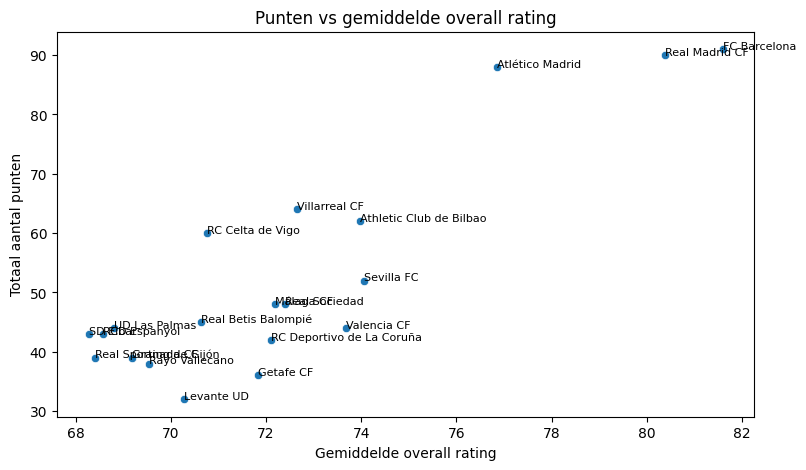

In [17]:
df = maak_dataset()

# Tabel voor overall rating
tabel_overall = df[[
    "team",
    "punten",
    "gemiddelde_overall_rating"
]].sort_values("punten", ascending=False)

display(tabel_overall)

# Visualisatie overall rating
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="gemiddelde_overall_rating",
    y="punten"
)

for index, rij in df.iterrows():
    plt.text(
        rij["gemiddelde_overall_rating"],
        rij["punten"],
        rij["team"],
        fontsize=8
    )

plt.title("Punten vs gemiddelde overall rating")
plt.xlabel("Gemiddelde overall rating")
plt.ylabel("Totaal aantal punten")
plt.show()


